<a href="https://colab.research.google.com/github/greinaldi/repositorio/blob/main/redesNeurais_Keras_classificacao_BalanceScale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classificação com Keras usando o conjunto de dados Balance Scale

Link: https://archive.ics.uci.edu/dataset/12/balance+scale

In [59]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import SGD

In [60]:
# Leitura do dataset
dados = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data',
                    names=['Class', 'Left-weight', 'Left-distance', 'Right-weight', 'Right-distance'])

In [61]:
# Visualização do dataset
dados.head()

,Class,Left-weight,Left-distance,Right-weight,Right-distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


In [62]:
# Definição dos atributos preditores e classe
x = dados.drop(columns=['Class'])
y = dados['Class']

In [63]:
y.value_counts()

,count
Class,
R,288
L,288
B,49


In [64]:
# Substituição dos valores de y para valores numéricos
y.replace('L', 0, inplace=True)
y.replace('R', 1, inplace=True)
y.replace('B', 2, inplace=True)

/tmp/ipython-input-34069168.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace('B', 2, inplace=True)


In [67]:
# Separação em bases de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, stratify=y)

In [68]:
# Dimensões dos dados
x_treino.shape, x_teste.shape, y_treino.shape, y_teste.shape

((500, 4), (125, 4), (500,), (125,))

In [69]:
# Conversão de y para matriz de três classes
y_treino_convertido = tf.keras.utils.to_categorical(y_treino)
y_teste_convertido = tf.keras.utils.to_categorical(y_teste)

In [70]:
# Matrizes convertidas de y: visualização
"Treino:", y_treino_convertido[0:5], "\n Teste:", y_teste_convertido[0:5]

('Treino:',
 array([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.]]),
 '\n Teste:',
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.]]))

In [71]:
# Definição de modelo
modelo = Sequential()

# 1ª Camada oculta: entrada dos dados
modelo.add(Dense(40, input_dim=4, kernel_initializer='normal', activation='relu'))

# 2ª Camada oculta
modelo.add(Dense(40, kernel_initializer='normal', activation='relu'))

# Camada de saída
modelo.add(Dense(3, kernel_initializer='normal', activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
# Otimizador
otimizador = SGD()

In [73]:
# Função de custo, otimizador e métrica de avaliação
modelo.compile(loss='categorical_crossentropy', optimizer=otimizador, metrics=['acc'])

In [74]:
# Treinamento do modelo
historico = modelo.fit(x_treino, y_treino_convertido, batch_size=500, epochs=1000, validation_data=(x_teste, y_teste_convertido))

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step - acc: 0.4560 - loss: 1.0928 - val_acc: 0.5040 - val_loss: 1.0912
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.4600 - loss: 1.0916 - val_acc: 0.4960 - val_loss: 1.0900
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - acc: 0.4580 - loss: 1.0904 - val_acc: 0.5040 - val_loss: 1.0889
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - acc: 0.4600 - loss: 1.0893 - val_acc: 0.5120 - val_loss: 1.0877
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - acc: 0.4600 - loss: 1.0881 - val_acc: 0.5280 - val_loss: 1.0865
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - acc: 0.4600 - loss: 1.0870 - val_acc: 0.5360 - val_loss: 1.0854
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - acc: 0.4580 - loss: 1.0858 - val_acc: 0.5280 - val_loss: 1.0843
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - acc: 0.4580 - loss: 1.0847 - val_acc: 0.5280 - val_loss: 1.0831
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - ac

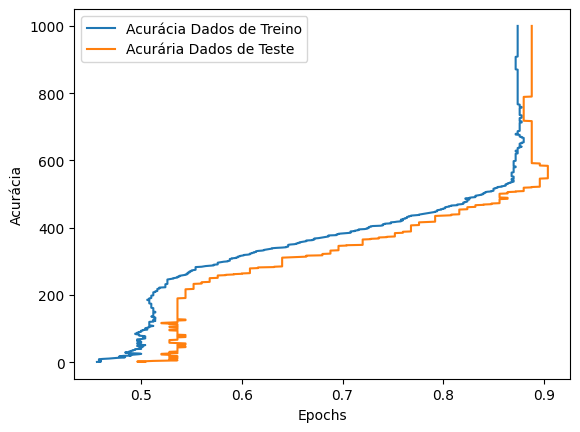

In [77]:
# Gráfico da acurácia dos modelos de treino e teste

# Eixos y
acuracia_treino = historico.history['acc']
acuracia_teste = historico.history['val_acc']

# Eixo x
epochs = range(1, len(acuracia_treino)+1)

plt.plot(acuracia_treino, epochs, label='Acurácia Dados de Treino')
plt.plot(acuracia_teste, epochs, label='Acurária Dados de Teste')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acurácia')
plt.show()

In [79]:
# Previsões
predicoes = modelo.predict(x_teste)
print(predicoes)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[[9.72562790e-01 5.58477174e-03 2.18523927e-02]
 [9.93542969e-01 6.59281155e-04 5.79770003e-03]
 [7.82253861e-01 1.34767190e-01 8.29787999e-02]
 [4.55987722e-01 3.93713593e-01 1.50298715e-01]
 [9.62642610e-01 9.41247772e-03 2.79449522e-02]
 [7.58069396e-01 1.23495921e-01 1.18434735e-01]
 [4.73005563e-01 4.08374399e-01 1.18620090e-01]
 [9.44231153e-01 1.51310628e-02 4.06376868e-02]
 [1.46755204e-01 7.72068202e-01 8.11765343e-02]
 [9.80475426e-01 3.45832226e-03 1.60661917e-02]
 [9.84136999e-01 2.56684027e-03 1.32960528e-02]
 [3.95190381e-02 9.08856392e-01 5.16245216e-02]
 [9.31312203e-01 2.97179390e-02 3.89698930e-02]
 [9.21476245e-01 2.46124342e-02 5.39112501e-02]
 [1.49751306e-01 7.81219840e-01 6.90289587e-02]
 [3.28214839e-02 9.30252492e-01 3.69259417e-02]
 [8.79538417e-01 4.50619198e-02 7.53995553e-02]
 [9.74804878e-01 5.14234509e-03 2.00528055e-02]
 [9.24760461e-01 2.84114424e-02 4.68281023e-02]
 [9.27024186e-01 2.96858959e-02 4.32899445e-02]
 [

In [80]:
np.set_printoptions(formatter={'float': lambda x: "{0:0.2f}".format(x)})
print(predicoes)

[[0.97 0.01 0.02]
 [0.99 0.00 0.01]
 [0.78 0.13 0.08]
 [0.46 0.39 0.15]
 [0.96 0.01 0.03]
 [0.76 0.12 0.12]
 [0.47 0.41 0.12]
 [0.94 0.02 0.04]
 [0.15 0.77 0.08]
 [0.98 0.00 0.02]
 [0.98 0.00 0.01]
 [0.04 0.91 0.05]
 [0.93 0.03 0.04]
 [0.92 0.02 0.05]
 [0.15 0.78 0.07]
 [0.03 0.93 0.04]
 [0.88 0.05 0.08]
 [0.97 0.01 0.02]
 [0.92 0.03 0.05]
 [0.93 0.03 0.04]
 [0.99 0.00 0.01]
 [0.96 0.01 0.03]
 [0.92 0.03 0.05]
 [0.45 0.40 0.16]
 [0.15 0.74 0.10]
 [0.95 0.01 0.04]
 [0.00 0.99 0.01]
 [0.01 0.96 0.03]
 [0.93 0.03 0.04]
 [0.90 0.04 0.06]
 [0.15 0.77 0.08]
 [0.97 0.01 0.02]
 [0.00 0.99 0.01]
 [0.03 0.93 0.04]
 [0.97 0.01 0.02]
 [0.77 0.14 0.10]
 [0.90 0.04 0.06]
 [0.99 0.00 0.01]
 [0.97 0.01 0.02]
 [0.44 0.45 0.12]
 [0.00 0.99 0.01]
 [0.03 0.93 0.04]
 [0.00 1.00 0.00]
 [0.95 0.01 0.04]
 [0.00 0.99 0.00]
 [0.46 0.44 0.10]
 [0.15 0.76 0.09]
 [0.98 0.00 0.01]
 [0.01 0.98 0.02]
 [0.95 0.01 0.04]
 [0.98 0.00 0.02]
 [0.16 0.76 0.09]
 [0.00 0.99 0.01]
 [0.01 0.98 0.01]
 [0.97 0.01 0.02]
 [0.03 0.9